In [4]:
pip install opencv-python

In [ ]:
pip install --upgrade --force-reinstall numpy==1.25.2 h5py==3.9.0 tensorflow==2.14.0


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 101.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
!pip install tensorflow

In [10]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import cv2
from google.colab.patches import cv2_imshow
import math
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score

#SHAPE CLASSIFICATION USING CNN

In [5]:
#  Paths
dataset_dir = "/content/drive/MyDrive/shapes_dataset"
model_save_path = "/content/drive/MyDrive/shapes_dataset/shape_classifier_cnn.keras"

img_size = 64
batch_size = 32

# Data Generator
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    dataset_dir,
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_gen = datagen.flow_from_directory(
    dataset_dir,
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

# CNN Model
model = Sequential([
    Conv2D(16, (3,3), activation="relu", input_shape=(img_size,img_size,1)),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(train_gen.num_classes, activation="softmax")
])

model.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

# Train CNN
history = model.fit(train_gen, validation_data=val_gen, epochs=15)

# Save Model
model.save(model_save_path)
print("Model saved at:", model_save_path)

# Evaluate
loss, acc = model.evaluate(val_gen)
print(f"Validation accuracy: {acc*100:.2f}%")

# 🔍 Generate Predictions for Validation Data
val_gen.reset()
pred_probs = model.predict(val_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

# Prediction Function
def predict_shape(img_path):
    img = image.load_img(img_path, target_size=(img_size,img_size), color_mode="grayscale")
    x = image.img_to_array(img)
    x = x / 255.0
    x = np.expand_dims(x, axis=0)
    preds = model.predict(x)
    class_idx = np.argmax(preds[0])
    class_label = list(train_gen.class_indices.keys())[class_idx]
    confidence = preds[0][class_idx]
    return class_label, confidence

# Example:
label, conf = predict_shape("/content/drive/MyDrive/shapes_dataset/basketball.jpg")
print(f"Predicted: {label} ({conf*100:.2f}%)")


Found 1440 images belonging to 6 classes.
Found 360 images belonging to 6 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,110 (1.22 MB)

 Trainable params: 319,110 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 268ms/step - accuracy: 0.3112 - loss: 1.6291 - val_accuracy: 0.5111 - val_loss: 1.1619
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 243ms/step - accuracy: 0.5958 - loss: 0.9440 - val_accuracy: 0.7000 - val_loss: 0.6157
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 237ms/step - accuracy: 0.7850 - loss: 0.4917 - val_accuracy: 0.8083 - val_loss: 0.4428
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 266ms/step - accuracy: 0.8286 - loss: 0.3737 - val_accuracy: 0.8083 - val_loss: 0.3813
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 253ms/step - accuracy: 0.8493 - loss: 0.3164 - val_accuracy: 0.8750 - val_loss: 0.3176
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 248ms/step - accuracy: 0.8668 - loss: 0.2707 - val_accuracy: 0.8528 - val_loss: 0.3225
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 246ms/step - accuracy: 0.9119 - loss: 0.2324 - val_accuracy: 0.8611 - val_loss: 0.3134
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 246ms/step - accuracy: 0.9034 - loss: 0.2210 - val_accu

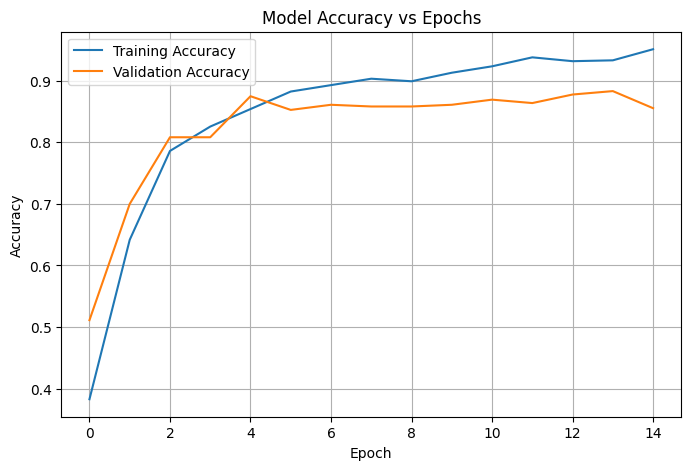

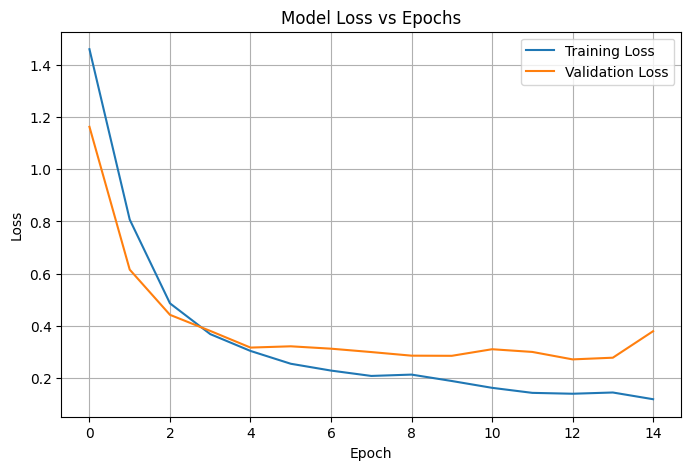

In [6]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot training & validation loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


#COUNT THE NUMBER OF OBJECTS IN A GIVEN IMAGE

Total objects detected: 12


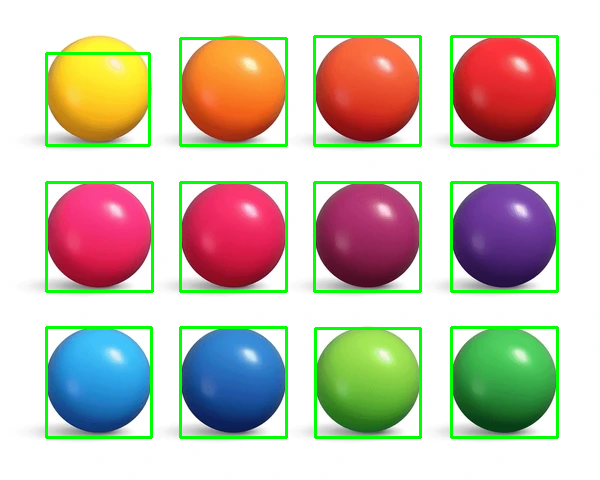

In [11]:
import cv2
from google.colab.patches import cv2_imshow

# Load image
image_path = "/content/drive/MyDrive/shapes_dataset/balls.jpg"
img = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Blur to reduce noise
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Apply threshold
_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

object_count = 0

for cnt in contours:
    area = cv2.contourArea(cnt)

    # Ignore unwanted tiny noise
    if area > 500:
        object_count += 1
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img, (x,y), (x+w, y+h), (0,255,0), 2)

print("Total objects detected:", object_count)

cv2_imshow(img)
cv2.waitKey(0)
cv2.destroyAllWindows()

#EXPLORATORY DATA ANALYSIS

Classes found: ['square', 'triangle', 'rectangle', 'hexagon', 'pentagon', 'circle']
       Class  Image Count
0     square          300
1   triangle          300
2  rectangle          300
3    hexagon          300
4   pentagon          300
5     circle          300


/tmp/ipython-input-286232937.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=count_df, x="Class", y="Image Count", palette="viridis")


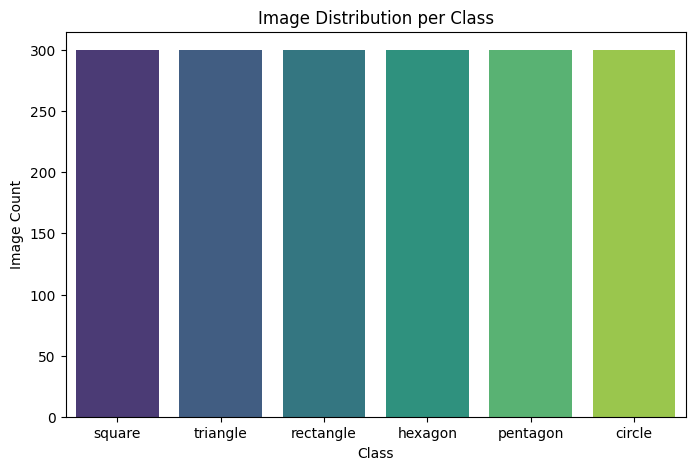


Image Size Summary:
        Width  Height
count  1800.0  1800.0
mean     64.0    64.0
std       0.0     0.0
min      64.0    64.0
25%      64.0    64.0
50%      64.0    64.0
75%      64.0    64.0
max      64.0    64.0


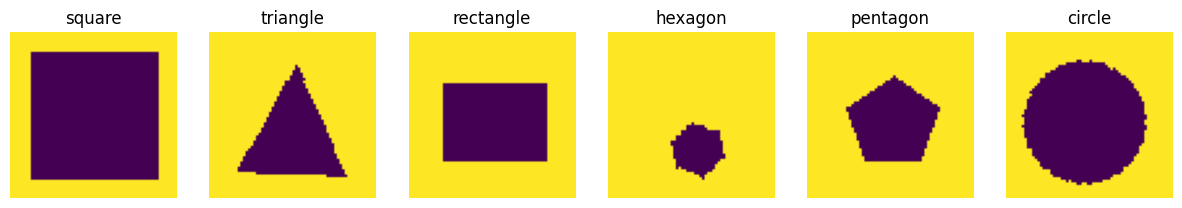

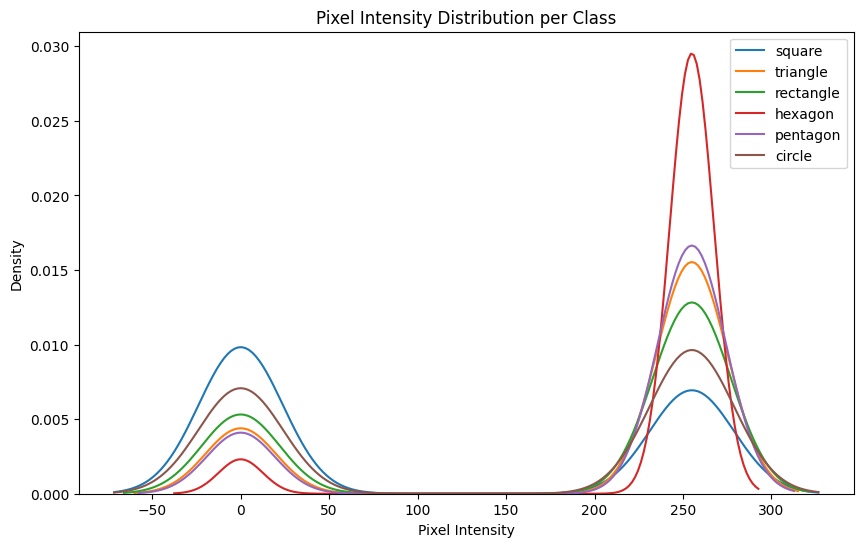

In [28]:

import seaborn as sns
import pandas as pd
from collections import Counter
from PIL import Image
import numpy as np

# Path to dataset
dataset_path = "/content/drive/MyDrive/shapes_dataset"

# Get all classes (folders)
classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

print("Classes found:", classes)

# Count images per class
image_counts = {}
for cls in classes:
    image_dir = os.path.join(dataset_path, cls)
    image_counts[cls] = len([f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

# Display counts
count_df = pd.DataFrame(list(image_counts.items()), columns=["Class", "Image Count"])
print(count_df)

# Plot distribution
plt.figure(figsize=(8,5))
sns.barplot(data=count_df, x="Class", y="Image Count", palette="viridis")
plt.title("Image Distribution per Class")
plt.show()

# Check image sizes
sizes = []
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            sizes.append(img.size)
        except:
            pass

size_df = pd.DataFrame(sizes, columns=["Width", "Height"])
print("\nImage Size Summary:")
print(size_df.describe())

# Visualize sample images
fig, axes = plt.subplots(1, len(classes), figsize=(15, 5))
for i, cls in enumerate(classes):
    cls_path = os.path.join(dataset_path, cls)
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.show()

# Check pixel intensity distribution
sample_images = []
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    sample_images.append(img.flatten())

plt.figure(figsize=(10,6))
for i, pixels in enumerate(sample_images):
    sns.kdeplot(pixels, label=classes[i])
plt.title("Pixel Intensity Distribution per Class")
plt.xlabel("Pixel Intensity")
plt.legend()
plt.show()


#CONFUSION MATRIX AND CLASSIFICATION REPORT

Found 360 images belonging to 6 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step
Classification Report:

              precision    recall  f1-score   support

      circle     0.8676    0.9833    0.9219        60
     hexagon     0.9655    0.9333    0.9492        60
    pentagon     1.0000    0.8833    0.9381        60
   rectangle     0.6316    0.8000    0.7059        60
      square     0.7273    0.5333    0.6154        60
    triangle     0.9836    1.0000    0.9917        60

    accuracy                         0.8556       360
   macro avg     0.8626    0.8556    0.8537       360
weighted avg     0.8626    0.8556    0.8537       360



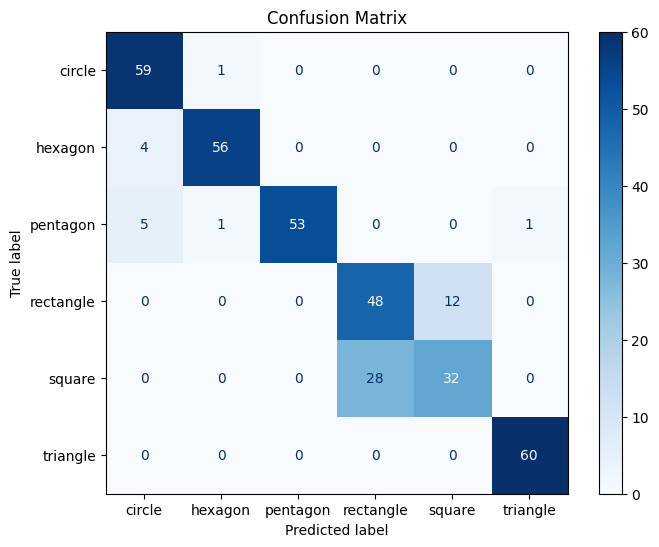

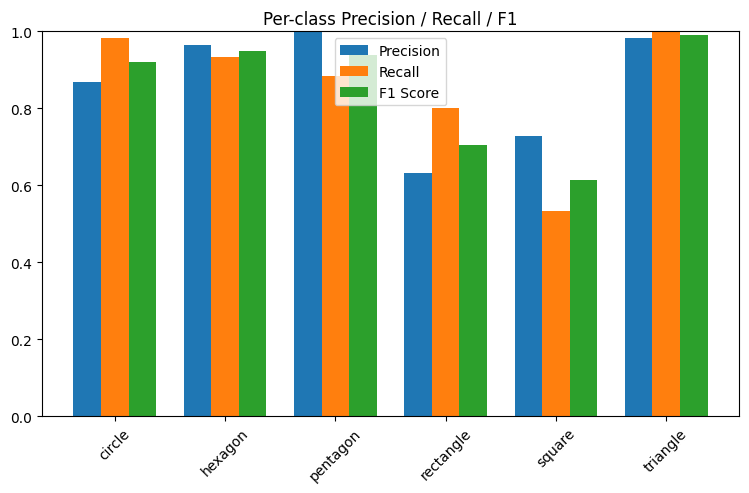

In [19]:
# Paths and params (change if needed)
dataset_dir = "/content/drive/MyDrive/shapes_dataset"   # or your dataset path
model_path = "/content/drive/MyDrive/shapes_dataset/shape_classifier_cnn.keras"
img_size = 64
batch_size = 32

# 1) Make a validation generator that matches training preprocessing and split
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_gen = datagen.flow_from_directory(
    dataset_dir,
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False   # IMPORTANT: no shuffling for evaluation
)

# 2) Load model
model = load_model(model_path)

# 3) Predict — ensure we predict exactly val_gen.samples images
steps = math.ceil(val_gen.samples / batch_size)
val_gen.reset()  # IMPORTANT: reset the generator before predict
pred_probs = model.predict(val_gen, steps=steps, verbose=1)

# 4) Convert preds -> class indices and true labels
y_pred = np.argmax(pred_probs, axis=1)
y_true = val_gen.classes  # in the same order because shuffle=False

# 5) Map index -> class name safely
idx_to_class = {v: k for k, v in val_gen.class_indices.items()}
class_labels = [idx_to_class[i] for i in range(len(idx_to_class))]

# 6) Confusion matrix and classification report
cm = confusion_matrix(y_true, y_pred)
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

# 7) Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, cmap="Blues", values_format='d')
plt.title("Confusion Matrix")
plt.show()

# 8) Optional: per-class precision/recall/f1 arrays and bar chart
precisions = precision_score(y_true, y_pred, average=None, zero_division=0)
recalls = recall_score(y_true, y_pred, average=None, zero_division=0)
f1s = f1_score(y_true, y_pred, average=None, zero_division=0)

x = np.arange(len(class_labels))
width = 0.25
plt.figure(figsize=(9,5))
plt.bar(x - width, precisions, width, label='Precision')
plt.bar(x, recalls, width, label='Recall')
plt.bar(x + width, f1s, width, label='F1 Score')
plt.xticks(x, class_labels, rotation=45)
plt.ylim(0, 1.0)
plt.title("Per-class Precision / Recall / F1")
plt.legend()
plt.show()


Found 360 images belonging to 6 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step

Classification Report:
               precision    recall  f1-score   support

      circle     0.8676    0.9833    0.9219        60
     hexagon     0.9655    0.9333    0.9492        60
    pentagon     1.0000    0.8833    0.9381        60
   rectangle     0.6316    0.8000    0.7059        60
      square     0.7273    0.5333    0.6154        60
    triangle     0.9836    1.0000    0.9917        60

    accuracy                         0.8556       360
   macro avg     0.8626    0.8556    0.8537       360
weighted avg     0.8626    0.8556    0.8537       360


Saved confusion matrix to: /content/drive/MyDrive/shapes_results/confusion_matrix.png
Saved classification report to: /content/drive/MyDrive/shapes_results/classification_report.txt
Saved misclassified samples list to: /content/drive/MyDrive/shapes_results/misclassified_samples.csv


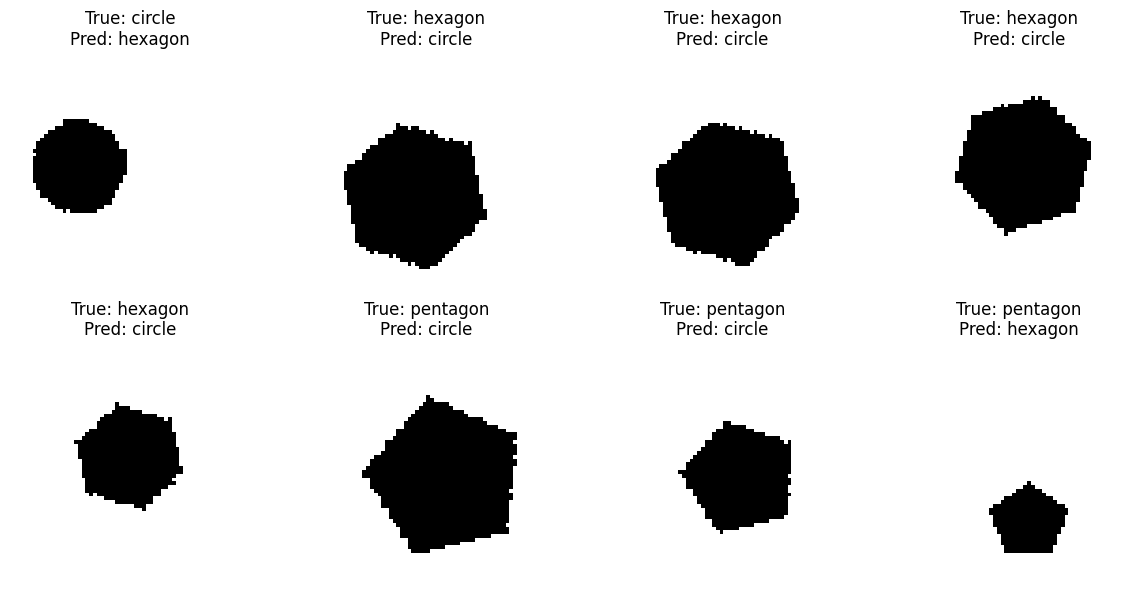

Saved sample misclassified image grid to: /content/drive/MyDrive/shapes_results/misclassified_examples.png


In [23]:
dataset_dir = "/content/drive/MyDrive/shapes_dataset"   # path to dataset
model_path = "/content/drive/MyDrive/shapes_dataset/shape_classifier_cnn.keras"
output_dir = "/content/drive/MyDrive/shapes_results"    # folder to save results
img_size = 64
batch_size = 32

os.makedirs(output_dir, exist_ok=True)

# 1. Load model and generator
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_gen = datagen.flow_from_directory(
    dataset_dir,
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

model = load_model(model_path)

# 2. Predict and evaluate
steps = math.ceil(val_gen.samples / batch_size)
val_gen.reset()
pred_probs = model.predict(val_gen, steps=steps, verbose=1)

y_pred = np.argmax(pred_probs, axis=1)
y_true = val_gen.classes

idx_to_class = {v: k for k, v in val_gen.class_indices.items()}
class_labels = [idx_to_class[i] for i in range(len(idx_to_class))]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, cmap="Blues", values_format='d')
plt.title("Confusion Matrix")
cm_path = os.path.join(output_dir, "confusion_matrix.png")
plt.savefig(cm_path, bbox_inches='tight')
plt.close(fig)

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_labels, digits=4)
report_path = os.path.join(output_dir, "classification_report.txt")
with open(report_path, "w") as f:
    f.write(report)
print("\nClassification Report:\n", report)
print(f"\nSaved confusion matrix to: {cm_path}")
print(f"Saved classification report to: {report_path}")

#Misclassified samples
filenames = np.array(val_gen.filenames)
misclassified_idx = np.where(y_pred != y_true)[0]

#DataFrame of misclassified examples
mis_df = pd.DataFrame({
    "filename": filenames[misclassified_idx],
    "true_label": [idx_to_class[i] for i in y_true[misclassified_idx]],
    "predicted_label": [idx_to_class[i] for i in y_pred[misclassified_idx]],
    "confidence": [np.max(pred_probs[i]) for i in misclassified_idx]
})

misclassified_csv_path = os.path.join(output_dir, "misclassified_samples.csv")
mis_df.to_csv(misclassified_csv_path, index=False)
print(f"Saved misclassified samples list to: {misclassified_csv_path}")

# 6. Visualize a few misclassified images
num_to_show = 8
plt.figure(figsize=(12, 6))

for i, idx in enumerate(misclassified_idx[:num_to_show]):
    img_path = os.path.join(dataset_dir, filenames[idx])
    img = image.load_img(img_path, color_mode="grayscale", target_size=(img_size, img_size))
    plt.subplot(2, 4, i + 1)
    plt.imshow(np.squeeze(img), cmap="gray")
    plt.title(f"True: {idx_to_class[y_true[idx]]}\nPred: {idx_to_class[y_pred[idx]]}")
    plt.axis("off")

plt.tight_layout()
mis_img_path = os.path.join(output_dir, "misclassified_examples.png")
plt.savefig(mis_img_path, bbox_inches="tight")
plt.show()
print(f"Saved sample misclassified image grid to: {mis_img_path}")
